# 03 — Feature Extraction
**Place in:** `ECG_Fatigue/notebooks/`

Reads each of the 748 cleaned alarm records from PhysioNet 2015,
extracts ~28 numerical features per record, and saves `Data/features.csv`.

That CSV is the input for `04_baseline_model.ipynb`.

In [1]:
# ── Cell 1: Imports & paths ───────────────────────────────────────────────────
import wfdb
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from scipy.signal import butter, filtfilt
from scipy.stats  import kurtosis, skew
from tqdm         import tqdm

PATH_2015    = '../Data/physionet2015'
PATH_RESULTS = '../results'
os.makedirs(PATH_RESULTS, exist_ok=True)

# Load cleaned record list from Phase 1
df_clean = pd.read_csv(f'{PATH_2015}/clean_records.csv')
print(f'Clean records loaded : {len(df_clean)}')
print(f'True alarms  (1)     : {(df_clean["label"]==1).sum()}')
print(f'False alarms (0)     : {(df_clean["label"]==0).sum()}')
print(f'Alarm types          : {df_clean["alarm_type"].value_counts().to_dict()}')
df_clean.head(3)

Clean records loaded : 748
True alarms  (1)     : 294
False alarms (0)     : 454
Alarm types          : {'Ventricular_Tachycardia': 340, 'Tachycardia': 140, 'Asystole': 121, 'Bradycardia': 89, 'Ventricular_Flutter_Fib': 58}


,record_id,label,alarm_type,n_channels,n_samples,duration_s,fs,has_nan,nan_pct,sig_names,ecg_min,ecg_max,ecg_std
0,v845l,0,Ventricular_Tachycardia,4,82500,330.0,250,False,0.0,"['II', 'V', 'ABP', 'RESP']",-0.430736,1.560823,0.240712
1,b578s,1,Bradycardia,4,75000,300.0,250,False,0.0,"['II', 'V', 'ABP', 'RESP']",-0.128098,1.215070,0.080588
2,f493l,0,Ventricular_Flutter_Fib,4,82500,330.0,250,False,0.0,"['II', 'V', 'ABP', 'RESP']",-0.605765,1.527273,0.538887


In [2]:
# ── Cell 2: Signal loader with NaN fix ───────────────────────────────────────
def load_clean_signal(record_path):
    """
    Load a wfdb record and fix NaN gaps with linear interpolation.
    Returns: signal array (n_samples, n_channels), sampling rate, channel names.
    """
    rec = wfdb.rdrecord(record_path)
    sig = rec.p_signal.copy()

    for ch in range(sig.shape[1]):
        col = pd.Series(sig[:, ch])
        if col.isna().all():
            sig[:, ch] = 0.0
        else:
            sig[:, ch] = col.interpolate(
                method='linear', limit_direction='both').values

    return sig, rec.fs, rec.sig_name

# Quick test
test_id = df_clean['record_id'].iloc[0]
sig, fs, names = load_clean_signal(f'{PATH_2015}/{test_id}')
print(f'Test record  : {test_id}')
print(f'Shape        : {sig.shape}  →  (samples, channels)')
print(f'Channels     : {names}')
print(f'Sample rate  : {fs} Hz')
print(f'Duration     : {sig.shape[0]/fs:.0f} seconds')
print(f'NaN remaining: {np.isnan(sig).sum()}')   # must be 0

Test record  : v845l
Shape        : (82500, 4)  →  (samples, channels)
Channels     : ['II', 'V', 'ABP', 'RESP']
Sample rate  : 250 Hz
Duration     : 330 seconds
NaN remaining: 0


In [3]:
# ── Cell 3: Signal processing helpers ────────────────────────────────────────
def bandpass_filter(signal, fs, lowcut=0.5, highcut=40.0):
    """Remove baseline wander (low-freq) and muscle noise (high-freq)."""
    nyq  = 0.5 * fs
    low  = lowcut  / nyq
    high = min(highcut / nyq, 0.99)
    b, a = butter(3, [low, high], btype='band')
    return filtfilt(b, a, signal)


def detect_rpeaks(ecg, fs):
    """
    Simple R-peak detector using threshold on squared + smoothed signal.
    Returns array of R-peak sample indices.
    """
    sq     = ecg ** 2
    win    = int(0.15 * fs)
    kernel = np.ones(win) / win
    smooth = np.convolve(sq, kernel, mode='same')

    threshold  = 0.6 * np.percentile(smooth, 98)
    above      = smooth > threshold
    crossings  = np.where(np.diff(above.astype(int)) == 1)[0]

    refractory = int(0.4 * fs)   # 400 ms minimum between beats
    peaks = []
    last  = -refractory
    for c in crossings:
        if c - last >= refractory:
            start = max(0, c - win//2)
            end   = min(len(ecg), c + win//2)
            peak  = start + np.argmax(sq[start:end])
            peaks.append(peak)
            last  = peak
    return np.array(peaks)

print('✅ Signal processing helpers defined')

✅ Signal processing helpers defined


In [4]:
# ── Cell 4: Feature extraction function ──────────────────────────────────────
def extract_features(rec_id, path, window_sec=30):
    """
    Extract a flat feature vector from one alarm record.
    Returns a dict of ~28 numerical features.

    Features cover:
      - Full-record ECG statistics (mean, std, energy, kurtosis, skew)
      - Heart rate from R-peaks (mean, std, min, max)
      - RR interval statistics (mean, std, RMSSD)
      - Arrhythmia indicators (short RR ratio, long RR ratio)
      - Last 30-second window features (alarm fires at end of recording)
      - SpO2 / PLETH channel statistics if present
      - ABP (blood pressure) channel statistics if present
    """
    sig, fs, ch_names = load_clean_signal(f'{path}/{rec_id}')
    feats = {'record_id': rec_id}

    # ── Identify channels ─────────────────────────────────────────────────
    ch_upper = [c.upper() for c in ch_names]
    ecg_ch   = next((i for i, c in enumerate(ch_upper)
                     if 'II' in c or 'ECG' in c or c == 'I'), 0)
    pleth_ch = next((i for i, c in enumerate(ch_upper)
                     if 'PLETH' in c or 'SPO2' in c or 'PLE' in c), None)
    abp_ch   = next((i for i, c in enumerate(ch_upper)
                     if 'ABP' in c or 'ART' in c or 'BP' in c), None)

    feats['has_pleth']  = int(pleth_ch is not None)
    feats['has_abp']    = int(abp_ch   is not None)
    feats['n_channels'] = sig.shape[1]

    # ── Full-record ECG features ──────────────────────────────────────────
    ecg_full = bandpass_filter(sig[:, ecg_ch], fs)
    feats['ecg_mean']     = float(np.mean(ecg_full))
    feats['ecg_std']      = float(np.std(ecg_full))
    feats['ecg_kurtosis'] = float(kurtosis(ecg_full))
    feats['ecg_skew']     = float(skew(ecg_full))
    feats['ecg_energy']   = float(np.mean(ecg_full ** 2))

    # ── Heart rate & RR interval features ────────────────────────────────
    peaks = detect_rpeaks(ecg_full, fs)
    if len(peaks) > 2:
        rr_ms = np.diff(peaks) / fs * 1000   # ms between beats
        hr    = 60000 / rr_ms                 # bpm

        feats['hr_mean']        = float(np.mean(hr))
        feats['hr_std']         = float(np.std(hr))
        feats['hr_min']         = float(np.min(hr))
        feats['hr_max']         = float(np.max(hr))
        feats['rr_mean']        = float(np.mean(rr_ms))
        feats['rr_std']         = float(np.std(rr_ms))
        feats['rmssd']          = float(np.sqrt(np.mean(np.diff(rr_ms)**2)))
        feats['n_peaks']        = len(peaks)
        feats['short_rr_ratio'] = float((rr_ms < 300).mean())   # VTach indicator
        feats['long_rr_ratio']  = float((rr_ms > 1500).mean())  # Bradycardia indicator
    else:
        for k in ['hr_mean','hr_std','hr_min','hr_max',
                  'rr_mean','rr_std','rmssd','n_peaks',
                  'short_rr_ratio','long_rr_ratio']:
            feats[k] = 0.0

    # ── Last 30-second window (alarm fires here) ──────────────────────────
    n_win   = int(window_sec * fs)
    ecg_win = ecg_full[-n_win:]

    feats['win_ecg_std']    = float(np.std(ecg_win))
    feats['win_ecg_energy'] = float(np.mean(ecg_win ** 2))

    peaks_win = detect_rpeaks(ecg_win, fs)
    if len(peaks_win) > 2:
        rr_win = np.diff(peaks_win) / fs * 1000
        feats['win_hr_mean']        = float(np.mean(60000 / rr_win))
        feats['win_rr_std']         = float(np.std(rr_win))
        feats['win_short_rr_ratio'] = float((rr_win < 300).mean())
        feats['win_long_rr_ratio']  = float((rr_win > 1500).mean())
    else:
        for k in ['win_hr_mean','win_rr_std',
                  'win_short_rr_ratio','win_long_rr_ratio']:
            feats[k] = 0.0

    # ── PLETH / SpO2 features ─────────────────────────────────────────────
    if pleth_ch is not None:
        pleth = sig[-n_win:, pleth_ch]
        feats['pleth_mean'] = float(np.nanmean(pleth))
        feats['pleth_std']  = float(np.nanstd(pleth))
    else:
        feats['pleth_mean'] = 0.0
        feats['pleth_std']  = 0.0

    # ── ABP / Blood pressure features ────────────────────────────────────
    if abp_ch is not None:
        abp = sig[-n_win:, abp_ch]
        feats['abp_mean'] = float(np.nanmean(abp))
        feats['abp_std']  = float(np.nanstd(abp))
        feats['abp_pp']   = float(np.nanmax(abp) - np.nanmin(abp))  # pulse pressure
    else:
        feats['abp_mean'] = 0.0
        feats['abp_std']  = 0.0
        feats['abp_pp']   = 0.0

    return feats

# Test on one record
test_feats = extract_features(df_clean['record_id'].iloc[0], PATH_2015)
print(f'Features extracted per record : {len(test_feats) - 1}')
print('Sample feature values:')
for k, v in list(test_feats.items())[1:8]:
    print(f'  {k:<20}: {v:.4f}')

Features extracted per record : 29
Sample feature values:
  has_pleth           : 0.0000
  has_abp             : 1.0000
  n_channels          : 4.0000
  ecg_mean            : 0.0003
  ecg_std             : 0.2274
  ecg_kurtosis        : 3.0946
  ecg_skew            : -0.9595


In [5]:
# ── Cell 5: Extract features from all 748 records ────────────────────────────
# Takes ~5–10 minutes on MacBook — do not interrupt

all_features = []
failed       = []

print(f'Extracting features from {len(df_clean)} records...')
print('This takes 5–10 minutes on MacBook CPU.\n')

for _, row in tqdm(df_clean.iterrows(), total=len(df_clean)):
    try:
        feats              = extract_features(row['record_id'], PATH_2015)
        feats['label']      = int(row['label'])
        feats['alarm_type'] = row['alarm_type']
        all_features.append(feats)
    except Exception as e:
        failed.append({'record_id': row['record_id'], 'error': str(e)})

df_features = pd.DataFrame(all_features)

print(f'\n✅ Extracted : {len(df_features)} records')
print(f'⚠️  Failed    : {len(failed)} records')
if failed:
    for f in failed[:5]:
        print(f'   {f["record_id"]} → {f["error"]}')

print(f'\nFeature matrix shape : {df_features.shape}')
print(f'Columns              : {list(df_features.columns)}')

Extracting features from 748 records...
This takes 5–10 minutes on MacBook CPU.



100%|██████████| 748/748 [00:27<00:00, 27.07it/s]


✅ Extracted : 748 records
⚠️  Failed    : 0 records

Feature matrix shape : (748, 32)
Columns              : ['record_id', 'has_pleth', 'has_abp', 'n_channels', 'ecg_mean', 'ecg_std', 'ecg_kurtosis', 'ecg_skew', 'ecg_energy', 'hr_mean', 'hr_std', 'hr_min', 'hr_max', 'rr_mean', 'rr_std', 'rmssd', 'n_peaks', 'short_rr_ratio', 'long_rr_ratio', 'win_ecg_std', 'win_ecg_energy', 'win_hr_mean', 'win_rr_std', 'win_short_rr_ratio', 'win_long_rr_ratio', 'pleth_mean', 'pleth_std', 'abp_mean', 'abp_std', 'abp_pp', 'label', 'alarm_type']


In [6]:
# ── Cell 6: Validate the feature matrix ──────────────────────────────────────
print('=' * 45)
print('FEATURE MATRIX VALIDATION')
print('=' * 45)

# Check NaN
nan_cols = df_features.isna().sum()
nan_cols = nan_cols[nan_cols > 0]
if len(nan_cols) == 0:
    print('✅  No NaN values in feature matrix')
else:
    print(f'⚠️  {len(nan_cols)} columns with NaN — filling with median')
    num_cols = df_features.select_dtypes(include=np.number).columns
    df_features[num_cols] = df_features[num_cols].fillna(
        df_features[num_cols].median())
    print('✅  NaN values filled')

# Class balance
print(f'\nClass balance:')
print(f'  True alarms  (1) : {(df_features["label"]==1).sum()}')
print(f'  False alarms (0) : {(df_features["label"]==0).sum()}')

# Feature stats by class
numeric_feats = ['hr_mean','hr_std','rr_std','rmssd',
                 'short_rr_ratio','long_rr_ratio','win_hr_mean']
print('\nMean feature values — True vs False alarm:')
print(df_features.groupby('label')[numeric_feats].mean().round(3).T.to_string())

FEATURE MATRIX VALIDATION
✅  No NaN values in feature matrix

Class balance:
  True alarms  (1) : 294
  False alarms (0) : 454

Mean feature values — True vs False alarm:
label                  0         1
hr_mean           64.995    74.195
hr_std            23.263    19.619
rr_std          6223.568  2441.398
rmssd           8511.697  3054.867
short_rr_ratio     0.000     0.000
long_rr_ratio      0.253     0.158
win_hr_mean       63.712    70.454


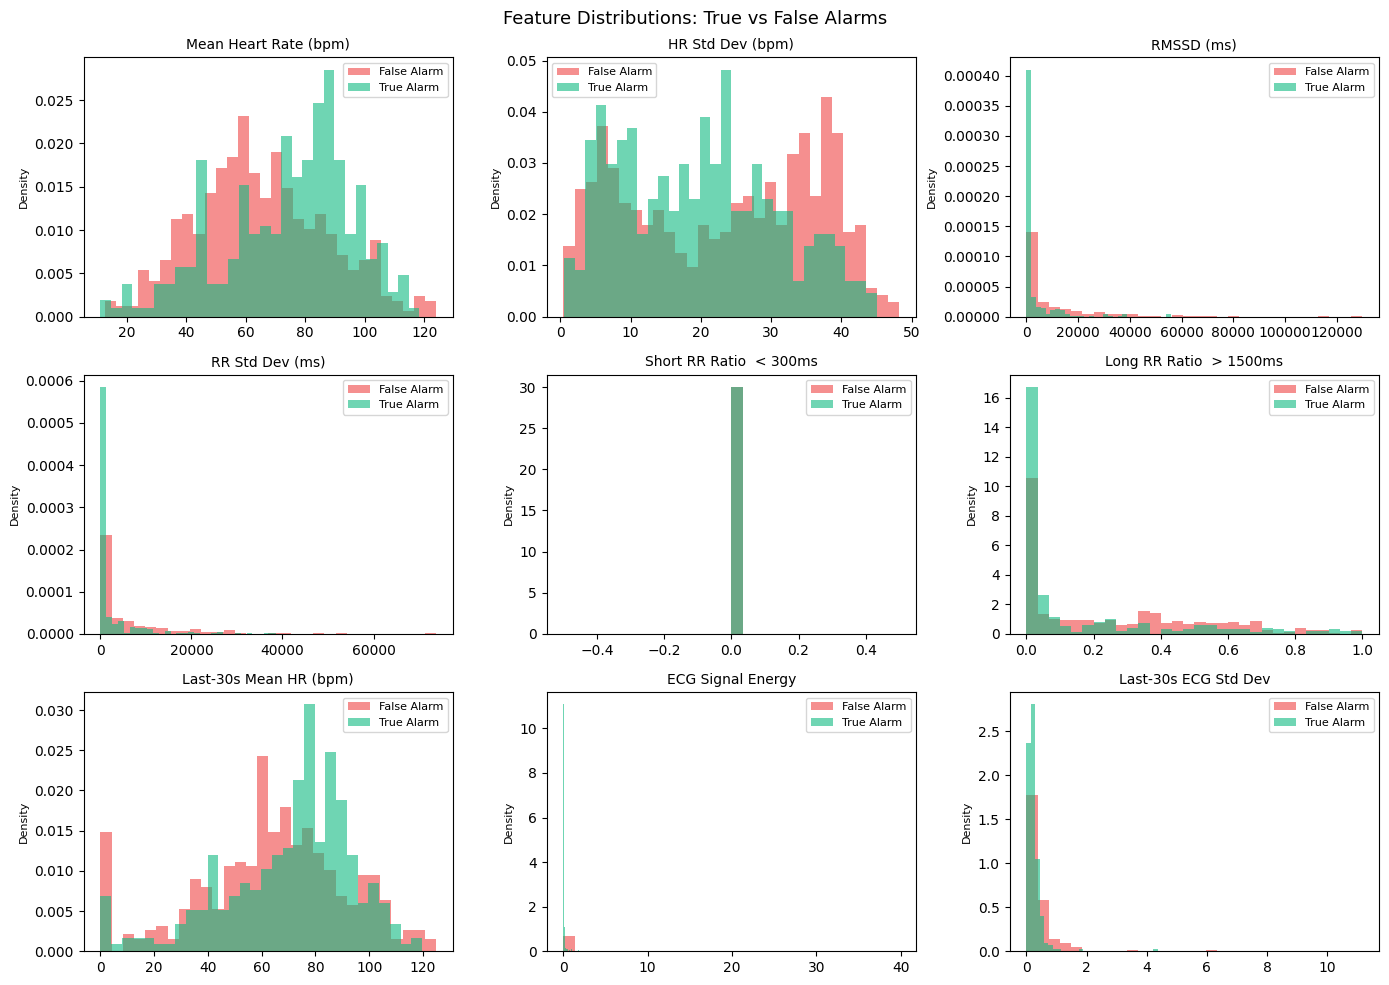

✅ Saved → ../results/03_feature_distributions.png


In [7]:
# ── Cell 7: Visualise feature distributions ───────────────────────────────────
features_to_plot = [
    ('hr_mean',          'Mean Heart Rate (bpm)'),
    ('hr_std',           'HR Std Dev (bpm)'),
    ('rmssd',            'RMSSD (ms)'),
    ('rr_std',           'RR Std Dev (ms)'),
    ('short_rr_ratio',   'Short RR Ratio  < 300ms'),
    ('long_rr_ratio',    'Long RR Ratio  > 1500ms'),
    ('win_hr_mean',      'Last-30s Mean HR (bpm)'),
    ('ecg_energy',       'ECG Signal Energy'),
    ('win_ecg_std',      'Last-30s ECG Std Dev'),
]

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for ax, (feat, title) in zip(axes, features_to_plot):
    true_v  = df_features[df_features['label']==1][feat].dropna()
    false_v = df_features[df_features['label']==0][feat].dropna()
    ax.hist(false_v, bins=30, alpha=0.6, color='#EF4444',
            label='False Alarm', density=True)
    ax.hist(true_v,  bins=30, alpha=0.6, color='#10B981',
            label='True Alarm',  density=True)
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=8)
    ax.set_ylabel('Density', fontsize=8)

plt.suptitle('Feature Distributions: True vs False Alarms', fontsize=13)
plt.tight_layout()
plt.savefig(f'{PATH_RESULTS}/03_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Saved → {PATH_RESULTS}/03_feature_distributions.png')

In [8]:
# ── Cell 8: Save features.csv ─────────────────────────────────────────────────
save_path = '../Data/features.csv'
df_features.to_csv(save_path, index=False)

print(f'✅ Saved → {os.path.abspath(save_path)}')
print(f'\nFinal shape    : {df_features.shape}')
print(f'Features       : {df_features.shape[1] - 3}  (minus record_id, label, alarm_type)')
print(f'True alarms    : {(df_features["label"]==1).sum()}')
print(f'False alarms   : {(df_features["label"]==0).sum()}')
print()
print('Next step → run 04_baseline_model.ipynb')

✅ Saved → /Users/adityasitapara/PycharmProjects/ECG_Fatigue/Backend/Data/features.csv

Final shape    : (748, 32)
Features       : 29  (minus record_id, label, alarm_type)
True alarms    : 294
False alarms   : 454

Next step → run 04_baseline_model.ipynb
